#### 데이터 준비
- 데이터를 다운로드하지 않고 가상의 데이터를 생성해서 실습

- 라이브러리 임포트
- 맷플롯립에서 한글 사용 => koreanize-matplotlib 설치 => !pip install koreanize-matplotlib

In [1]:
!pip install koreanize-matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

- 2026년 2월 1일부터 7일까지 1시간 간격으로 시간 데이터 생성

In [4]:
dates = pd.date_range('2026-2-1', '2026-2-7 23:00:00' , freq='h')
dates

DatetimeIndex(['2026-02-01 00:00:00', '2026-02-01 01:00:00',
               '2026-02-01 02:00:00', '2026-02-01 03:00:00',
               '2026-02-01 04:00:00', '2026-02-01 05:00:00',
               '2026-02-01 06:00:00', '2026-02-01 07:00:00',
               '2026-02-01 08:00:00', '2026-02-01 09:00:00',
               ...
               '2026-02-07 14:00:00', '2026-02-07 15:00:00',
               '2026-02-07 16:00:00', '2026-02-07 17:00:00',
               '2026-02-07 18:00:00', '2026-02-07 19:00:00',
               '2026-02-07 20:00:00', '2026-02-07 21:00:00',
               '2026-02-07 22:00:00', '2026-02-07 23:00:00'],
              dtype='datetime64[ns]', length=168, freq='h')

- 10부터 50미만의 dates 개수만큼의 가상 데이터 생성( 8시와 18시 출퇴근시간에 대여량이 급증 )

In [11]:
dates.hour

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       ...
       14, 15, 16, 17, 18, 19, 20, 21, 22, 23],
      dtype='int32', length=168)

In [14]:
rng = np.random.default_rng(0)
counts = rng.integers(10, 50, len(dates)) + (dates.hour == 8) * 70 + (dates.hour == 18) * 85
counts

array([ 44,  35,  30,  20,  22,  11,  13,  10,  87,  42,  35,  46,  30,
        34,  48,  39,  35,  31, 117,  47,  21,  42,  36,  10,  25,  44,
        32,  11,  40,  39,  43,  17,  83,  44,  10,  31,  13,  21,  29,
        26,  26,  11,  95,  14,  10,  36,  31,  35,  20,  34,  40,  25,
        28,  49,  42,  49,  95,  37,  48,  36,  43,  37,  38,  25,  45,
        15, 118,  38,  43,  31,  25,  22,  26,  29,  38,  45,  12,  47,
        31,  24, 106,  32,  20,  22,  38,  33,  30,  23,  40,  25, 108,
        45,  20,  19,  38,  34,  11,  13,  25,  43,  26,  41,  22,  19,
       111,  45,  13,  12,  36,  23,  32,  16,  44,  28, 130,  41,  38,
        19,  40,  12,  32,  26,  49,  17,  47,  13,  34,  33, 115,  21,
        46,  36,  45,  17,  40,  47,  11,  24, 120,  14,  30,  35,  40,
        47,  26,  27,  28,  48,  17,  29,  11,  27, 117,  34,  23,  49,
        34,  47,  10,  28,  43,  40, 111,  29,  26,  31,  19,  41])

- 데이터프레임으로 합치기

In [17]:
df = pd.DataFrame({'datetime':dates, 'count':counts})
df.head()

,datetime,count
0,2026-02-01 00:00:00,44
1,2026-02-01 01:00:00,35
2,2026-02-01 02:00:00,30
3,2026-02-01 03:00:00,20
4,2026-02-01 04:00:00,22


#### 시간데이터 뽑아내기 - 0시부터 23시까지 시간별로 대여량의 평균 구하기

- 데이터프레임 datetime열에는 연도, 월, 일, 시간이 모두 섞여 있음. 우리가 궁금한 것은 몇시에 가장 많이 대여하는지 여부
- 시간 정보만 따로 분리해 보자 ( .dt.hour : 시간, .dt.dayofweek : 요일 )

In [18]:
df['hour'] = df['datetime'].dt.hour
df.head(30)

,datetime,count,hour
0,2026-02-01 00:00:00,44,0
1,2026-02-01 01:00:00,35,1
2,2026-02-01 02:00:00,30,2
3,2026-02-01 03:00:00,20,3
4,2026-02-01 04:00:00,22,4
5,2026-02-01 05:00:00,11,5
6,2026-02-01 06:00:00,13,6
7,2026-02-01 07:00:00,10,7
8,2026-02-01 08:00:00,87,8
9,2026-02-01 09:00:00,42,9


- 시간으로 그룹으로 묶고, 대여량의 평균구하기

In [20]:
hour_avg = df.groupby('hour')['count'].mean()
hour_avg

hour
0      26.285714
1      29.714286
2      34.571429
3      29.857143
4      27.428571
5      32.714286
6      28.000000
7      25.571429
8     102.000000
9      36.428571
10     27.857143
11     33.142857
12     34.142857
13     30.285714
14     32.428571
15     29.142857
16     34.857143
17     24.857143
18    114.142857
19     32.571429
20     26.857143
21     30.428571
22     32.714286
23     28.714286
Name: count, dtype: float64

#### 시간 흐름에 따른 대여량 변화를 꺾은선 그래프로 시각화

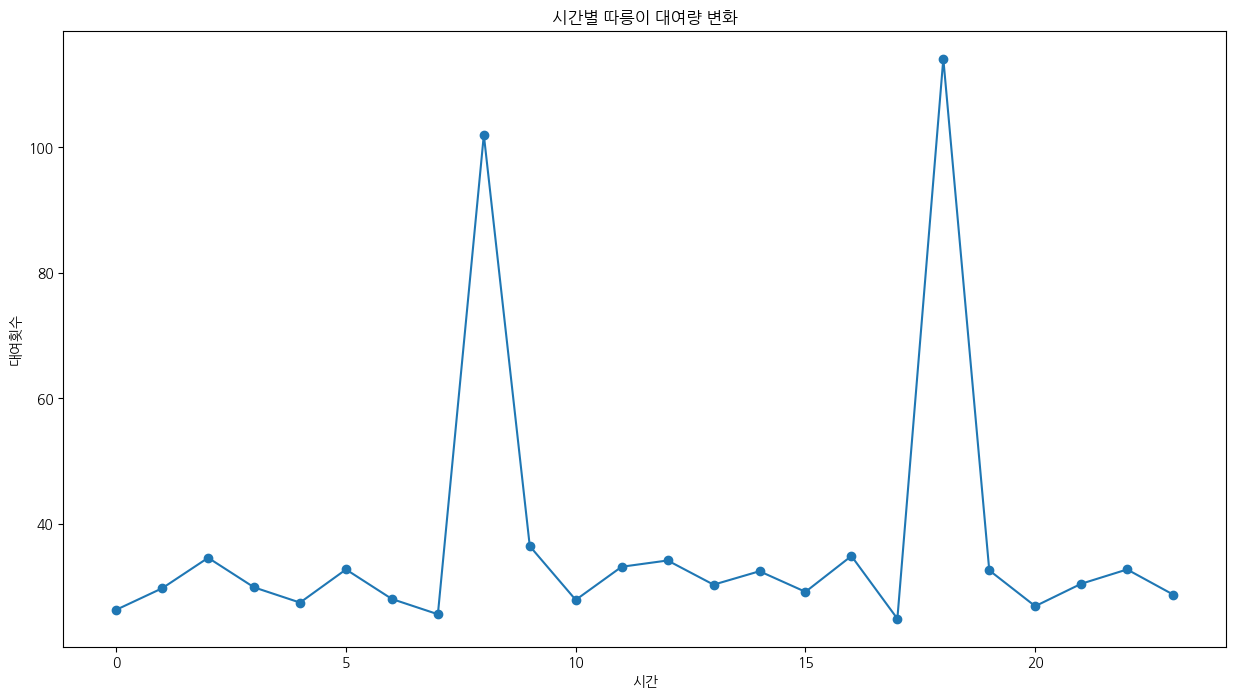

In [24]:
plt.figure(figsize=(15,8))
plt.plot(hour_avg, marker='o')
plt.title('시간별 따릉이 대여량 변화')
plt.xlabel('시간')
plt.ylabel('대여횟수')
plt.show()